<a href="https://colab.research.google.com/github/MahdiMashayekhi-AI/Machine-Learning-Projects/blob/main/01-data-preprocessing/data-visualization/Visualization_Using_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualization Using **Seaborn**

## Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Loading the dataset and EDA

In [3]:
df = sns.load_dataset('tips') # Load the default dataset of seaborn
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
df.dtypes

,0
total_bill,float64
tip,float64
sex,category
smoker,category
day,category
time,category
size,int64


In [5]:
df.shape

(244, 7)

In [6]:
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [7]:
df.duplicated().sum() # Some orders may be the same!

np.int64(1)

In [8]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## Histogram for Univariate Numeric Var

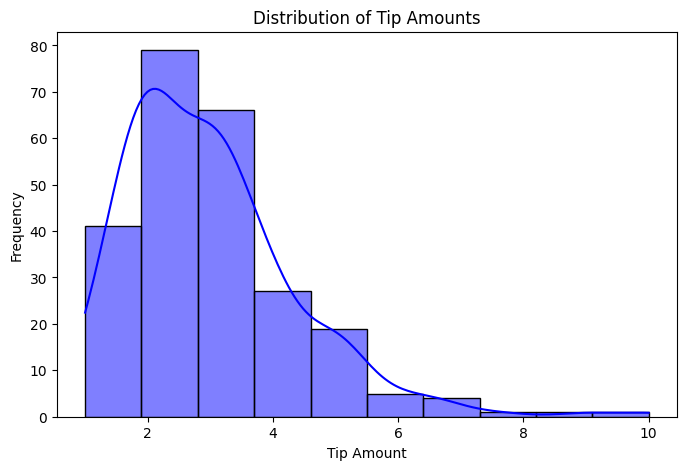

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['tip'], bins=10, kde=True, color='b')
plt.xlabel('Tip Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Tip Amounts')
plt.show()

## Density Plot for Univariate Numeric Var

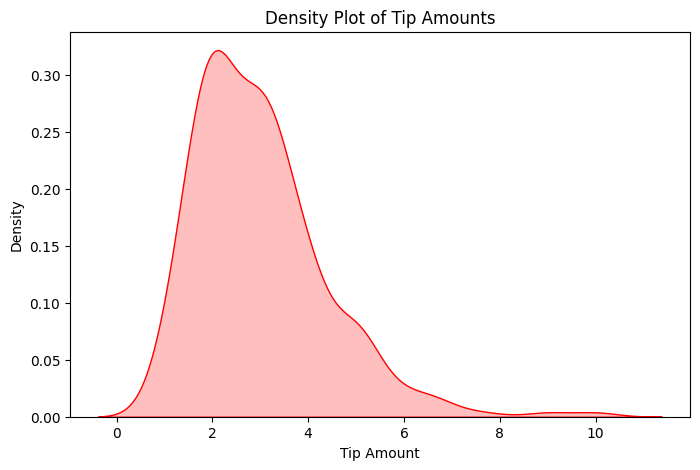

In [10]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['tip'], color='r', fill=True) # Known as Density plot
plt.xlabel('Tip Amount')
plt.ylabel('Density')
plt.title('Density Plot of Tip Amounts')
plt.show()

## Box plot for Univariate Numeric Var

/tmp/ipython-input-11-1412965298.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='tip', data=df, palette='Set2')


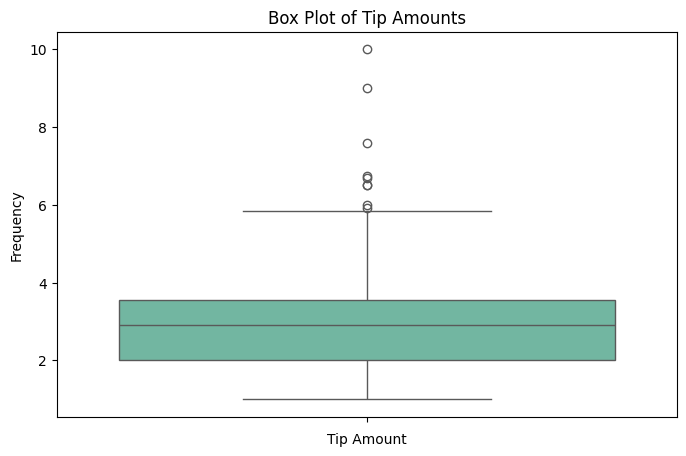

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(y='tip', data=df, palette='Set2')
plt.xlabel('Tip Amount')
plt.ylabel('Frequency')
plt.title('Box Plot of Tip Amounts')
plt.show()

## Function to create Histogram, Density, and Box plot

In [12]:
def plot_hist_kde_box(column_name):
  data = df[column_name]

  fig, axis = plt.subplots(1, 3, figsize=(15, 5))

  sns.histplot(data, bins=10, kde=True, ax=axis[0], color='b')
  axis[0].set_title('Histogram')

  sns.kdeplot(data, ax=axis[1], color='r', fill=True)
  axis[1].set_title('Kernel Density Estimation')

  sns.boxplot(data, ax=axis[2], palette='Set2')
  axis[2].set_title('Box Plot')

  plt.tight_layout()
  plt.show()

/tmp/ipython-input-12-3565656757.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data, ax=axis[2], palette='Set2')


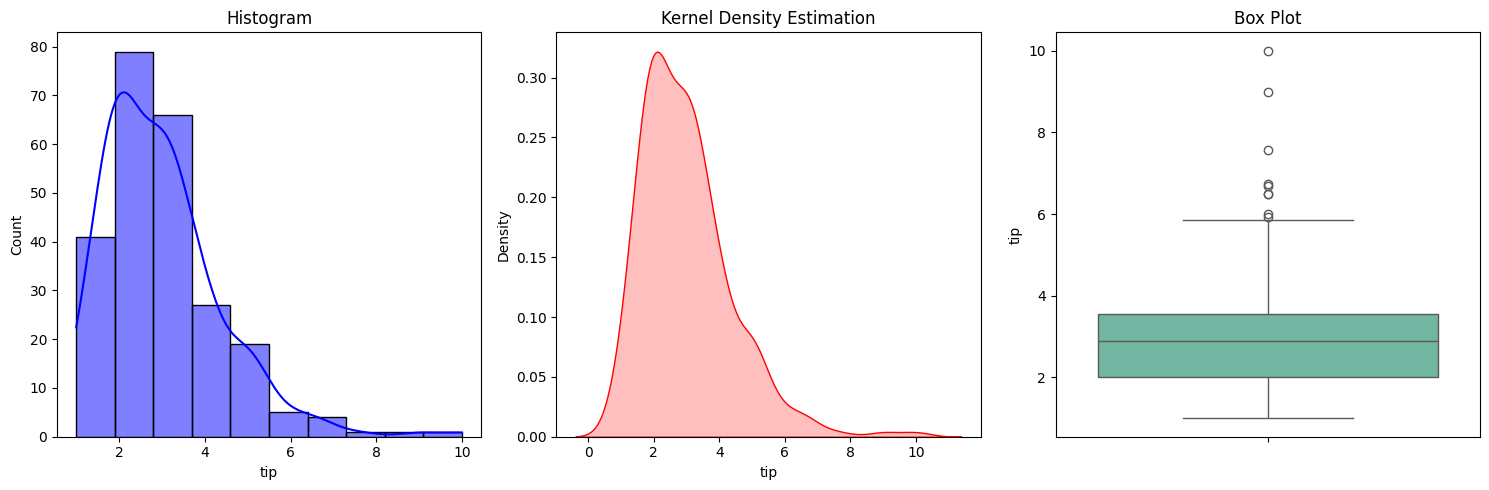

In [13]:
plot_hist_kde_box('tip')

/tmp/ipython-input-12-3565656757.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data, ax=axis[2], palette='Set2')


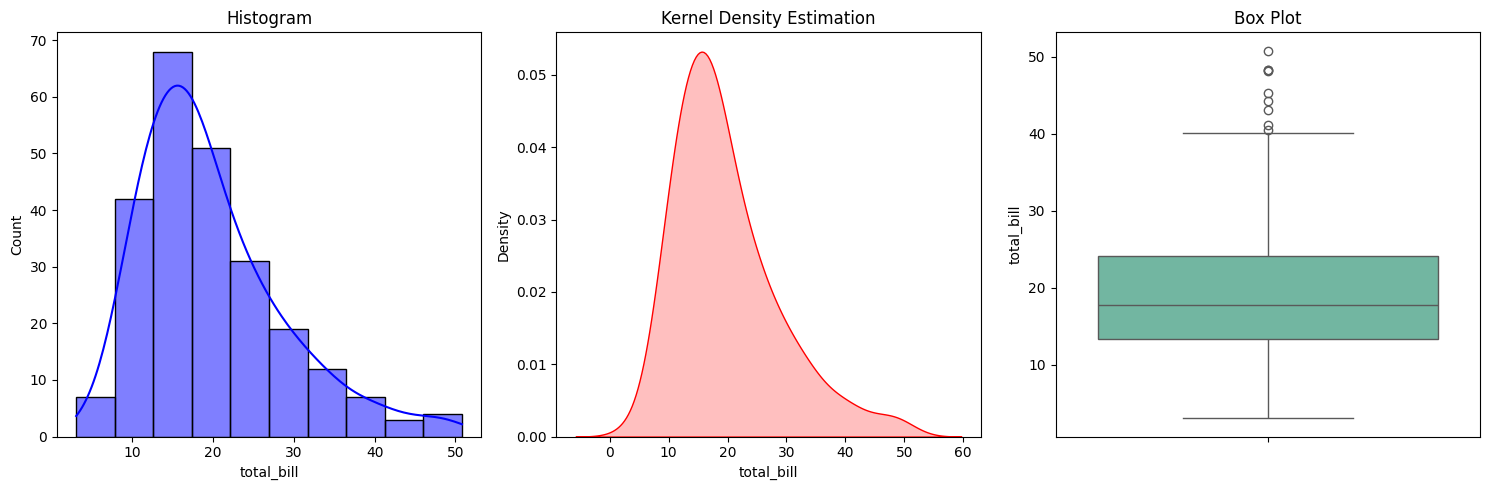

In [14]:
plot_hist_kde_box('total_bill')

/tmp/ipython-input-12-3565656757.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data, ax=axis[2], palette='Set2')


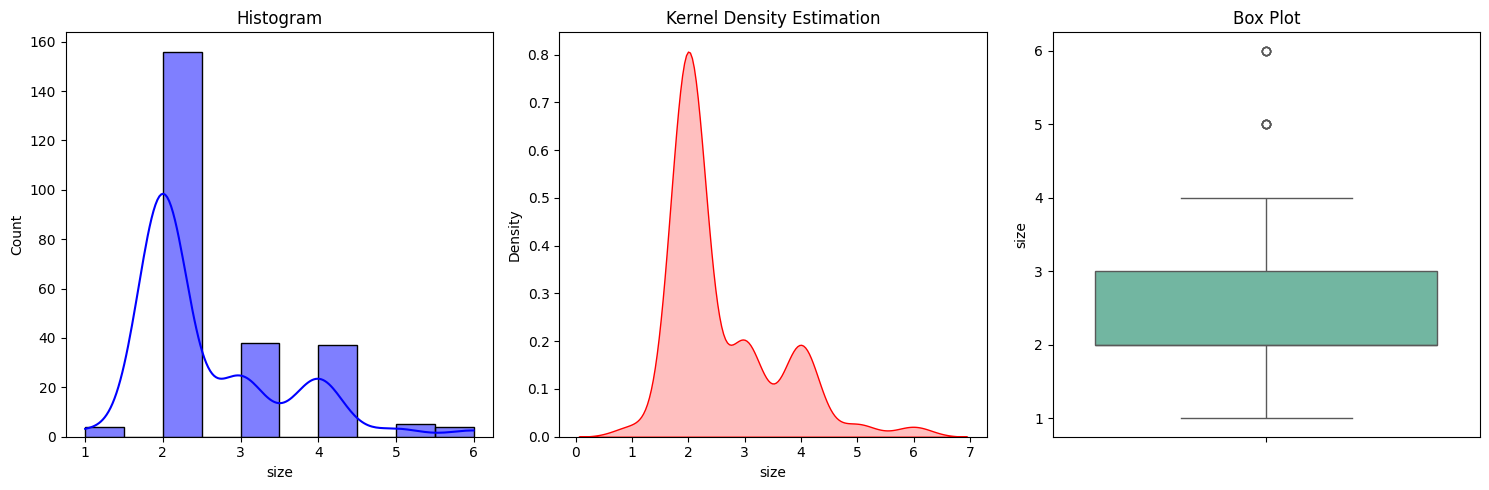

In [15]:
plot_hist_kde_box('size')

## Create plots with Subplots

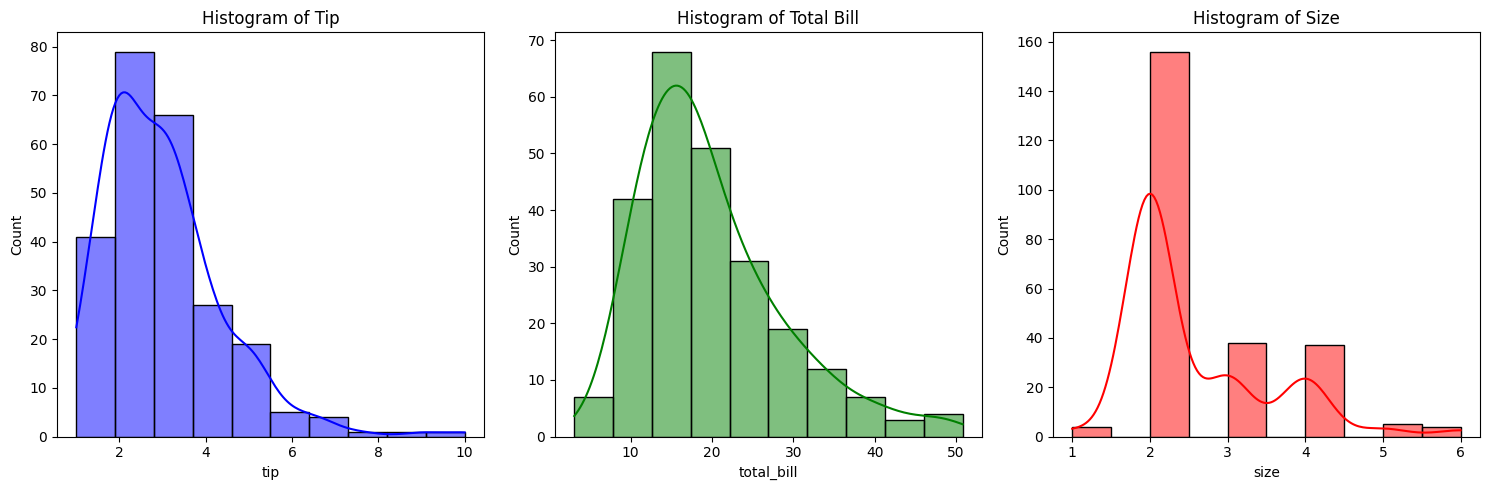

In [16]:
fig, axis = plt.subplots(1, 3, figsize=(15,5))

sns.histplot(df['tip'], bins=10, kde=True, ax=axis[0], color='b')
axis[0].set_title('Histogram of Tip')

sns.histplot(df['total_bill'], bins=10, kde=True, ax=axis[1], color='g')
axis[1].set_title('Histogram of Total Bill')

sns.histplot(df['size'], bins=10, kde=True, ax=axis[2], color='r')
axis[2].set_title('Histogram of Size')

plt.tight_layout()
plt.show()

## Count plot for categorical var

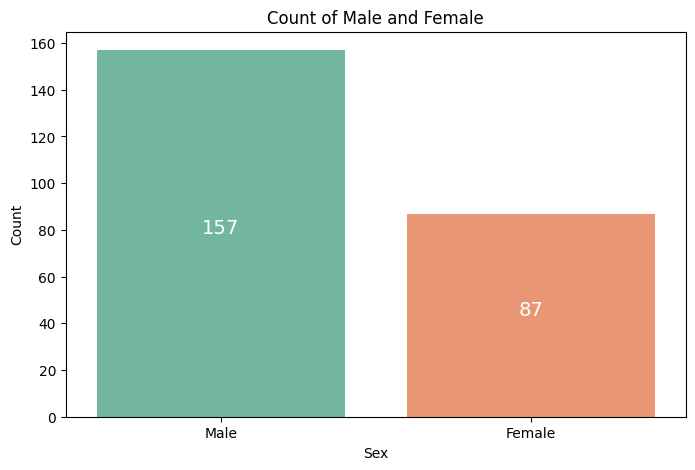

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x='sex', hue='sex', data=df, palette='Set2')

for i, count in enumerate(df['sex'].value_counts()):
  plt.text(i, count / 2, str(count), ha='center', color='white', fontsize=14)
#          x axis,y axis,your text, h align
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Count of Male and Female')
plt.show()

## Pie plot for categorical var (Seaborn does not have pie plot!)

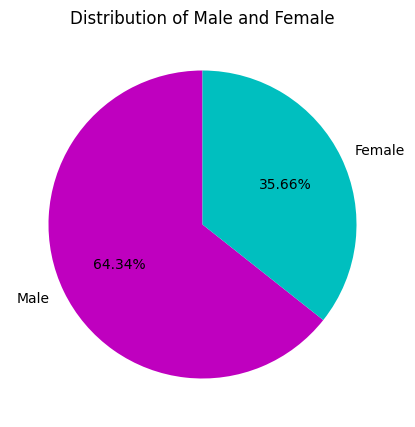

In [18]:
plt.figure(figsize=(8,5))
plt.pie(df['sex'].value_counts(), colors=['m', 'c'], labels=df['sex'].value_counts().index, autopct='%0.2f%%', startangle=90)
plt.title('Distribution of Male and Female')
plt.show()

## Function to create count, and pie plot

In [19]:
def plot_count_pie(column_name):
  plt.figure(figsize=(15,5))

  plt.subplot(1, 2, 1)
  plt.pie(df[column_name].value_counts(), colors=['m', 'c'], labels=df[column_name].value_counts().index, autopct='%0.2f%%', startangle=90)
  plt.title(f'Pie Plot of {column_name}')

  plt.subplot(1, 2, 2)
  sns.countplot(x=column_name, hue=column_name, data=df, palette='Set2')
  plt.xlabel(column_name)
  plt.ylabel('Count')
  plt.title(f'Count of {column_name}')

  plt.tight_layout()
  plt.show()

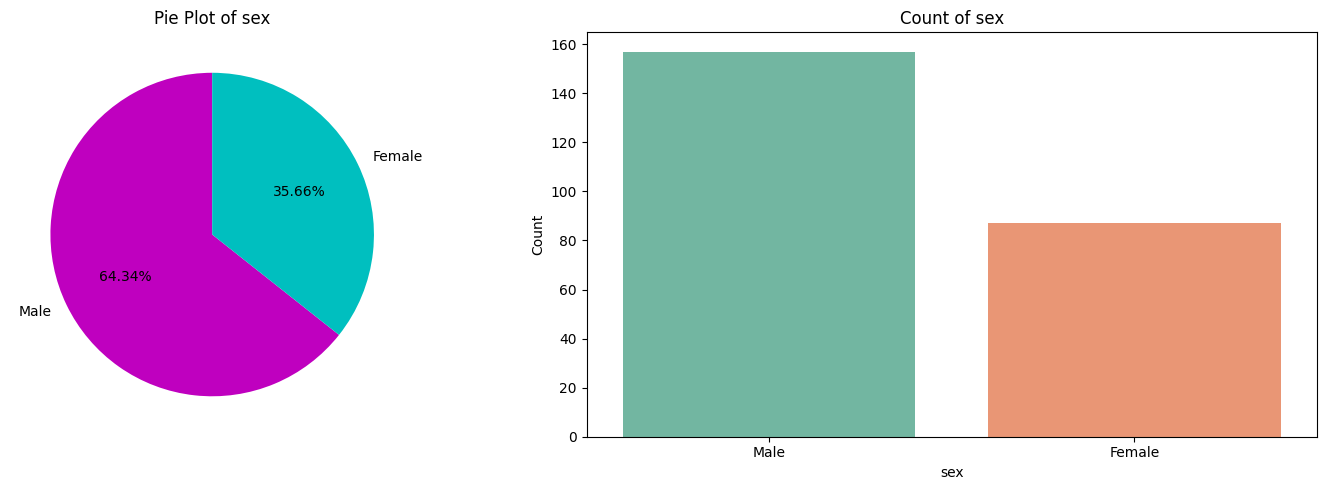

In [20]:
plot_count_pie('sex')

In [21]:
df['smoker'].value_counts()

,count
smoker,
No,151
Yes,93


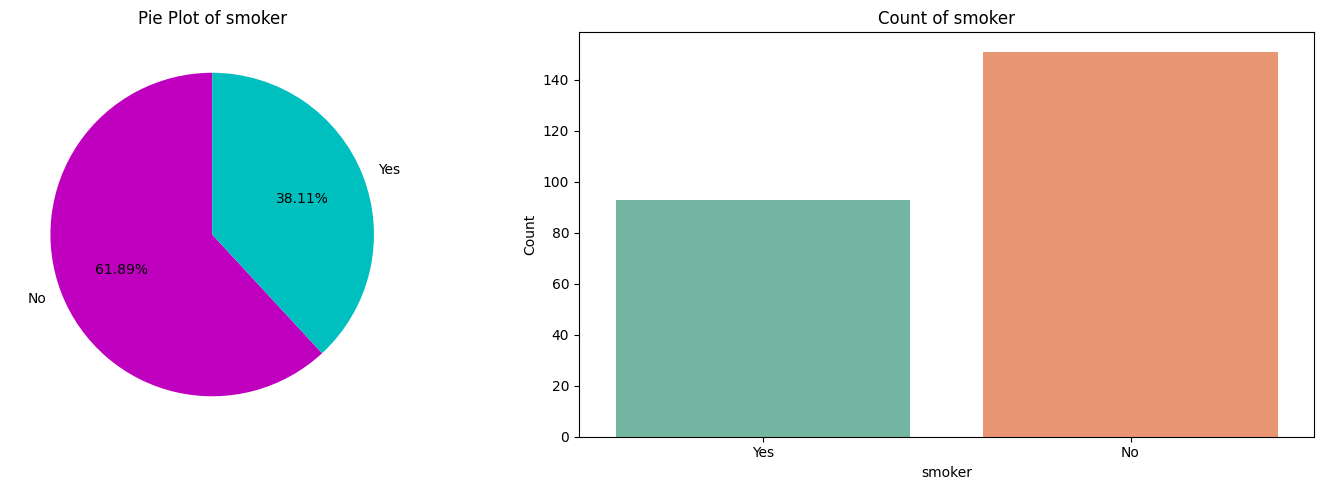

In [22]:
plot_count_pie('smoker')

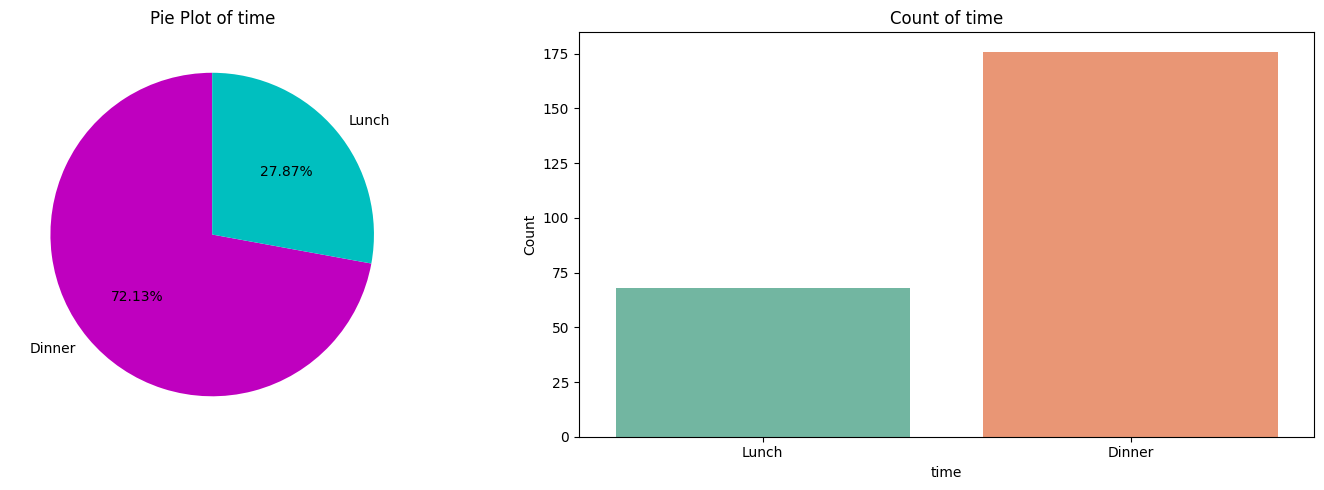

In [23]:
plot_count_pie('time')

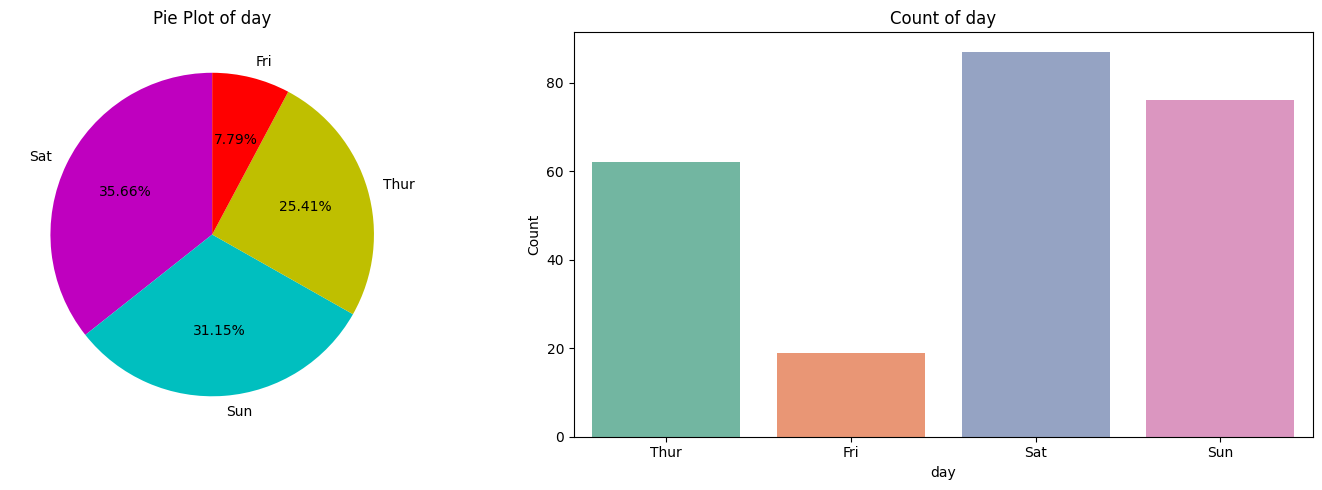

In [24]:
column_name = 'day'

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.pie(df[column_name].value_counts(), colors=['m', 'c', 'y', 'r'], labels=df[column_name].value_counts().index, autopct='%0.2f%%', startangle=90)
plt.title(f'Pie Plot of {column_name}')

plt.subplot(1, 2, 2)
sns.countplot(x=column_name, hue=column_name, data=df, palette='Set2')
plt.xlabel(column_name)
plt.ylabel('Count')
plt.title(f'Count of {column_name}')

plt.tight_layout()
plt.show()

## Create pie plot for all categorical columns

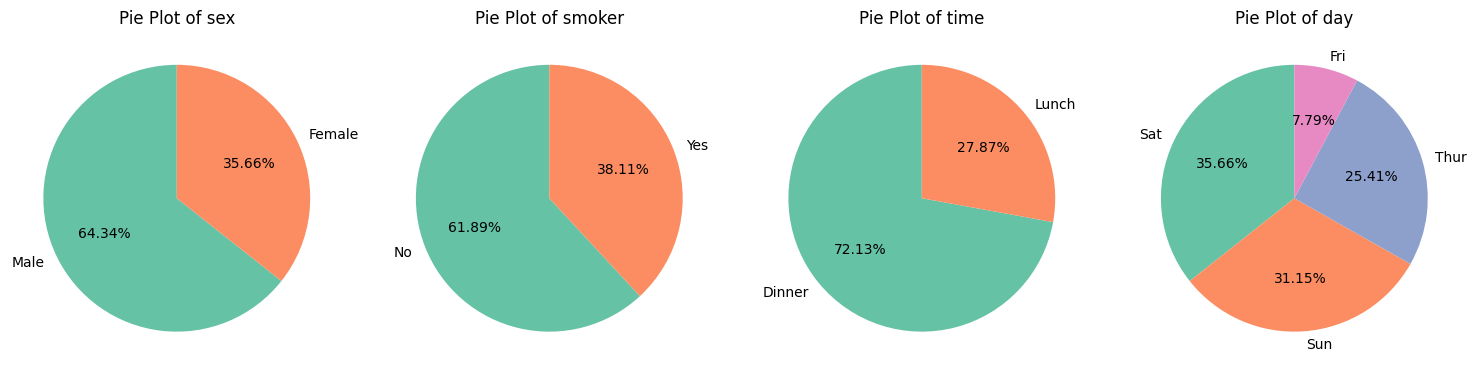

In [25]:
fig, axis = plt.subplots(1, 4, figsize=(15,5))
column_name = ['sex', 'smoker', 'time', 'day']

for i, col in enumerate(column_name):
  axis[i].pie(df[col].value_counts(), labels=df[col].value_counts().index, autopct='%0.2f%%', startangle=90, colors=sns.color_palette('Set2'))
  axis[i].set_title(f'Pie Plot of {col}')

plt.tight_layout()
plt.show()

## Scatter plot with regression line

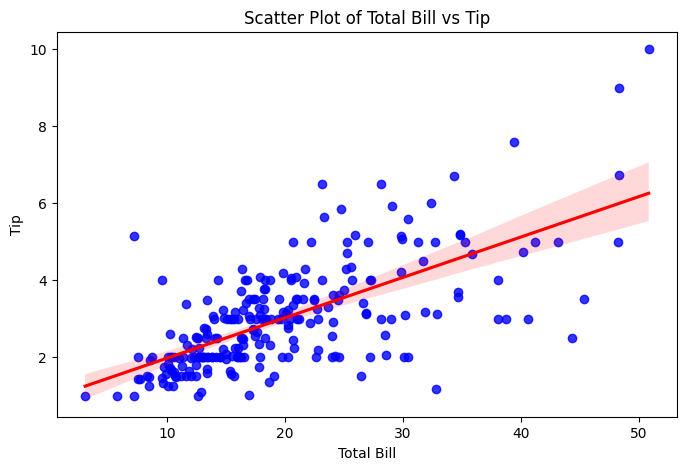

In [26]:
plt.figure(figsize=(8,5))
sns.regplot(x='total_bill', y='tip', data=df, scatter_kws={'color': 'b'}, line_kws={'color': 'r'})
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Scatter Plot of Total Bill vs Tip')
plt.show()

## Box plot for categorical and numerical data

/tmp/ipython-input-27-872157744.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='size', y='tip', data=df, palette='Set2')


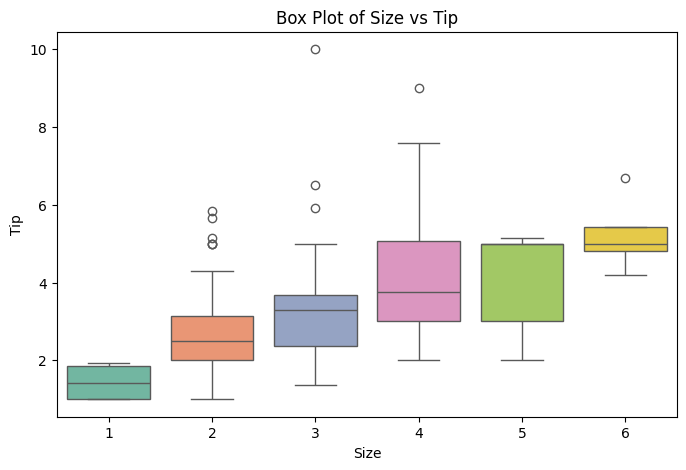

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x='size', y='tip', data=df, palette='Set2')
plt.xlabel('Size')
plt.ylabel('Tip')
plt.title('Box Plot of Size vs Tip')
plt.show()

## Bar plot for categorical and numerical data

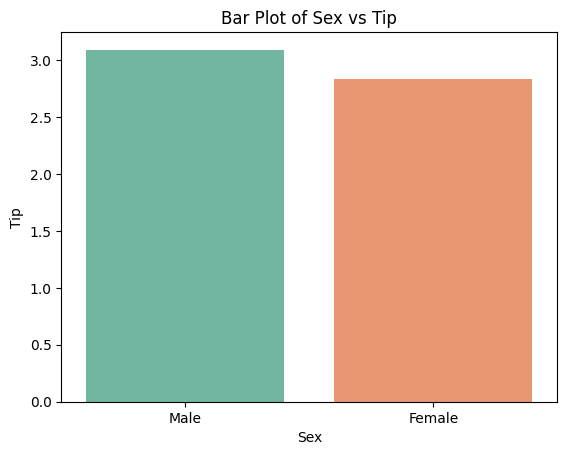

In [28]:
sns.barplot(x='sex', y='tip', hue='sex', data=df, palette='Set2', errorbar=None)
plt.xlabel('Sex')
plt.ylabel('Tip')
plt.title('Bar Plot of Sex vs Tip')
plt.show()

## Function to create box plot of a numerical feature with other categorical data

In [29]:
def boxplot_with_tip(column_name):
  plt.figure(figsize=(8,5))
  sns.boxplot(x=column_name, y='tip', hue=column_name, data=df, palette='Set2')
  plt.xlabel(column_name)
  plt.ylabel('Tip')
  plt.title(f'Box Plot of {column_name} vs Tip')
  plt.show()

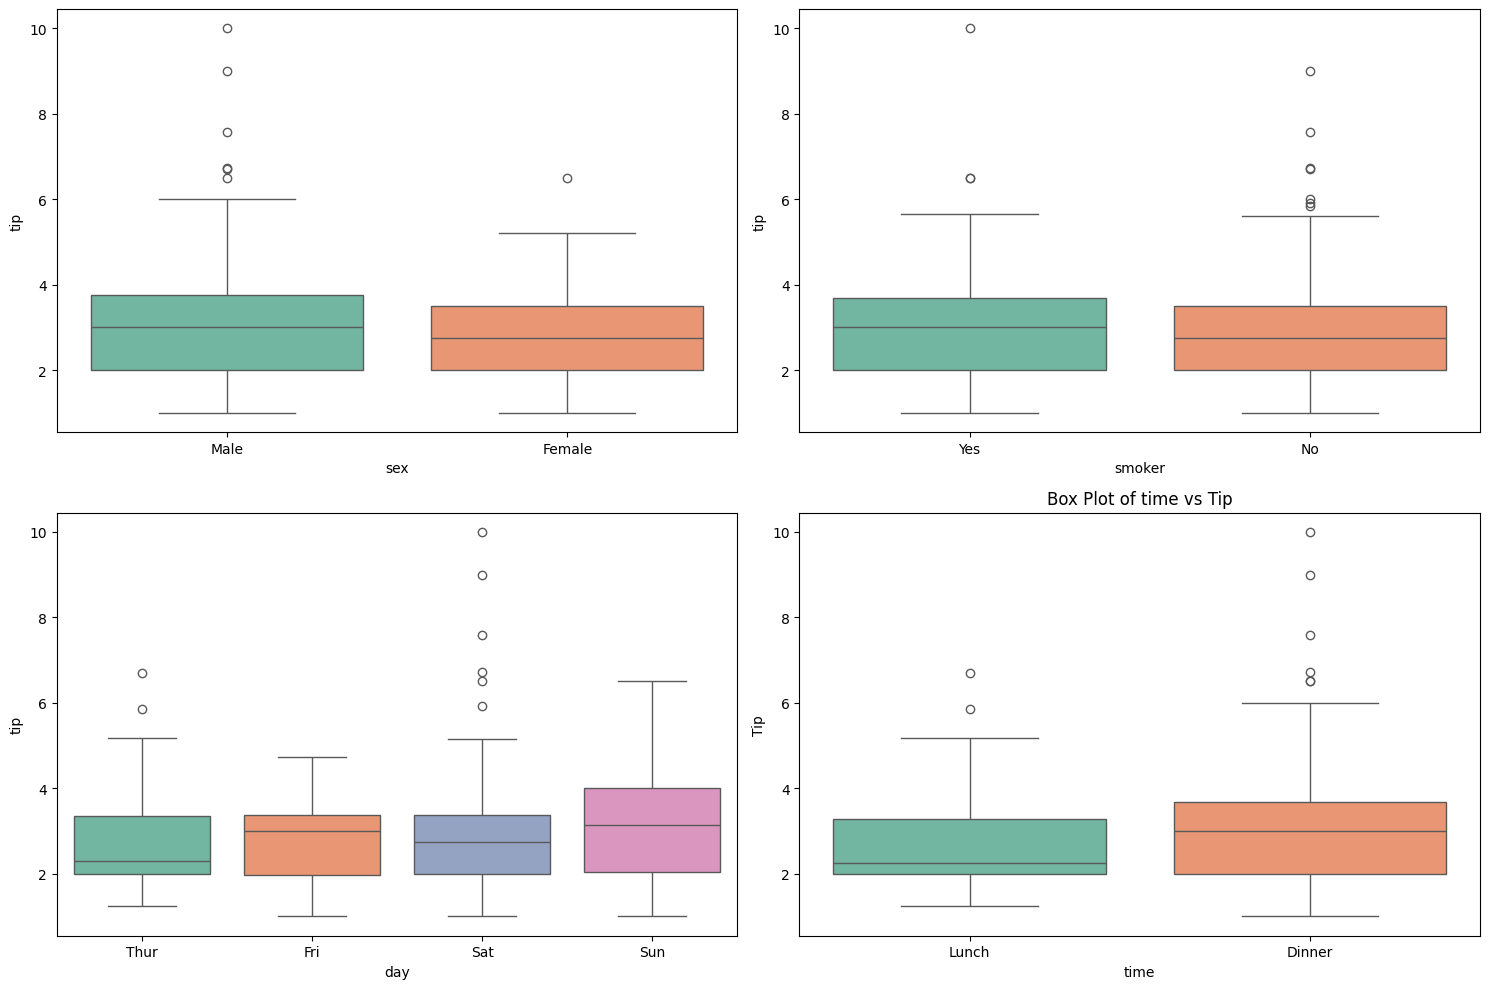

In [30]:
column_names_to_box = ['sex',	'smoker',	'day', 'time']
fig, axes = plt.subplots(2, 2, figsize=(15,10))

axes = axes.flatten()

for i, column_name in enumerate(column_names_to_box):
  sns.boxplot(x=column_name, y='tip', ax=axes[i], hue=column_name, data=df, palette='Set2')
  plt.xlabel(column_name)
  plt.ylabel('Tip')
  plt.title(f'Box Plot of {column_name} vs Tip')

plt.tight_layout()
plt.show()

## Create a ratio of each column to the total and Create stack bar

In [31]:
pd.crosstab(df['day'], df['time'], normalize=True)

time,Lunch,Dinner
day,,
Thur,0.250000,0.004098
Fri,0.028689,0.049180
Sat,0.000000,0.356557
Sun,0.000000,0.311475


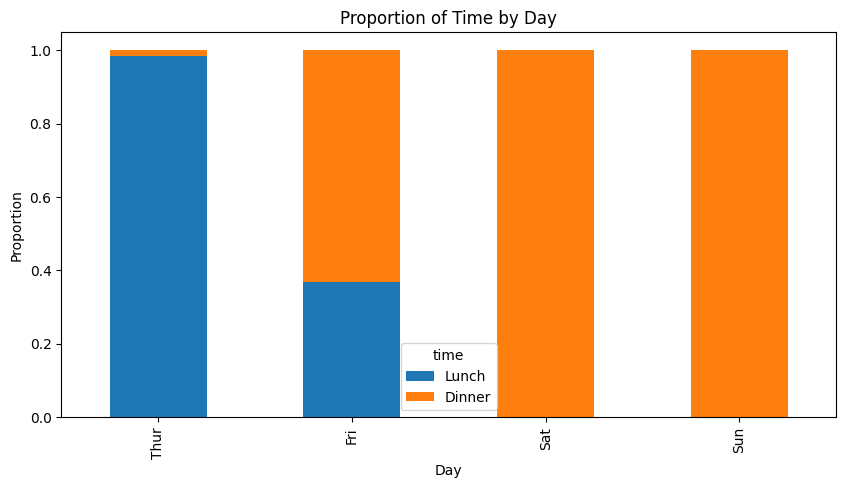

In [32]:
ct = pd.crosstab(df['day'], df['time'], normalize='index')
ct.plot(kind='bar', stacked=True, figsize=(10,5))
plt.xlabel('Day')
plt.ylabel('Proportion')
plt.title('Proportion of Time by Day')
plt.show()

## Get correlation matrix and create heatmap

In [33]:
 corr_matrix = df.select_dtypes(include=['number']).corr()
 corr_matrix

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


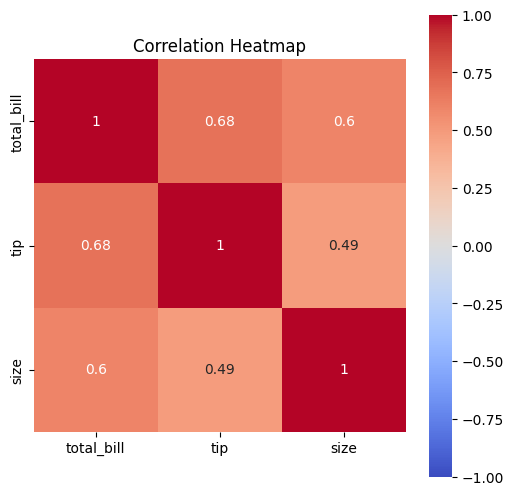

In [34]:
plt.figure(figsize=(6, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True, vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

## Scatter plot with linear model

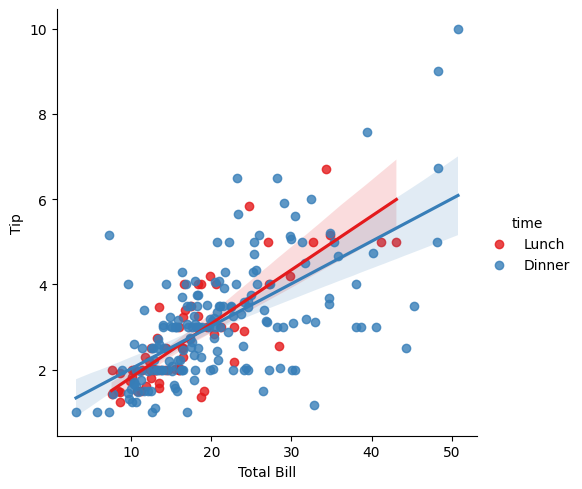

In [35]:
sns.lmplot(x='total_bill', y='tip', data=df, hue='time', palette='Set1')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.show()

## Pari plot for corrolations

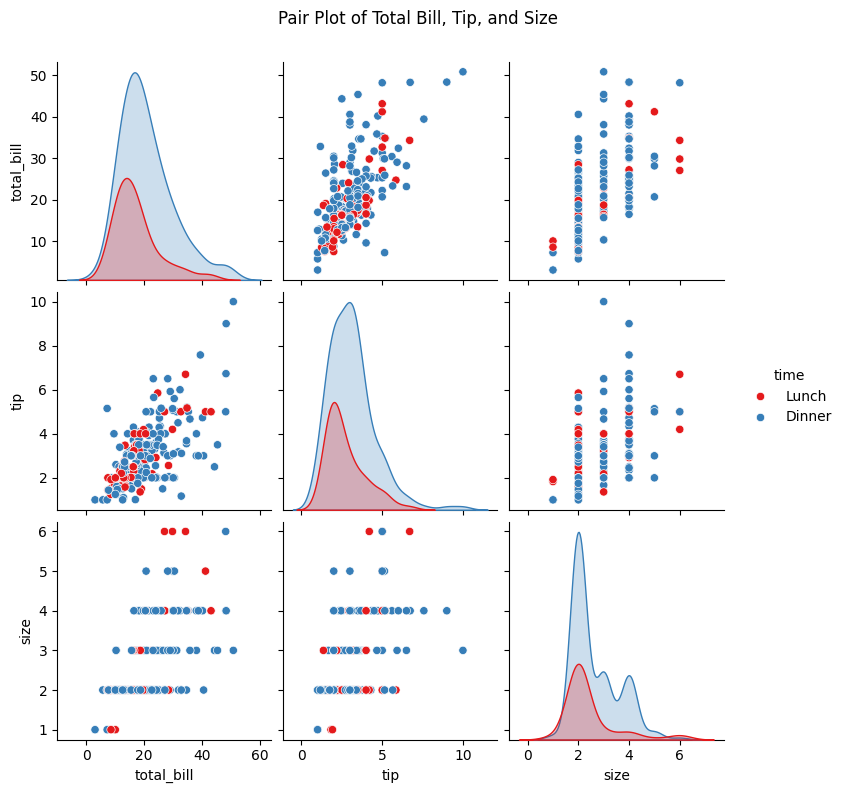

In [36]:
q = sns.pairplot(df, vars=['total_bill', 'tip', 'size'], hue='time', diag_kind='kde', palette='Set1')
q.fig.suptitle('Pair Plot of Total Bill, Tip, and Size', y=1.05)
plt.show()

## Simple scatter plot without a line

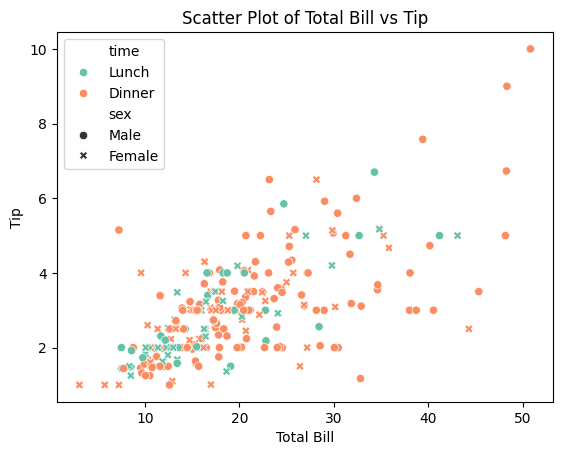

In [37]:
sns.scatterplot(x='total_bill', y='tip', data=df, hue='time', palette='Set2', style='sex')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Scatter Plot of Total Bill vs Tip')
plt.show()

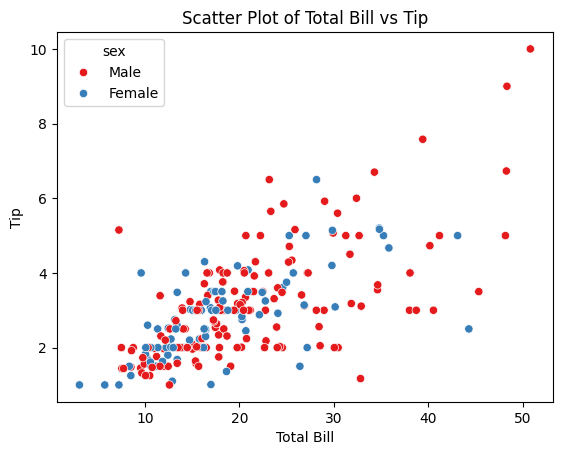

In [38]:
sns.scatterplot(x='total_bill', y='tip', data=df, hue='sex', palette='Set1')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Scatter Plot of Total Bill vs Tip')
plt.show()

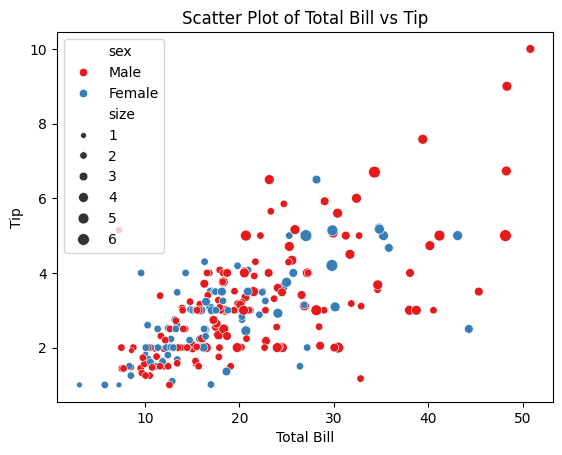

In [39]:
sns.scatterplot(x='total_bill', y='tip', data=df, hue='sex', size='size', palette='Set1')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Scatter Plot of Total Bill vs Tip')
plt.show()

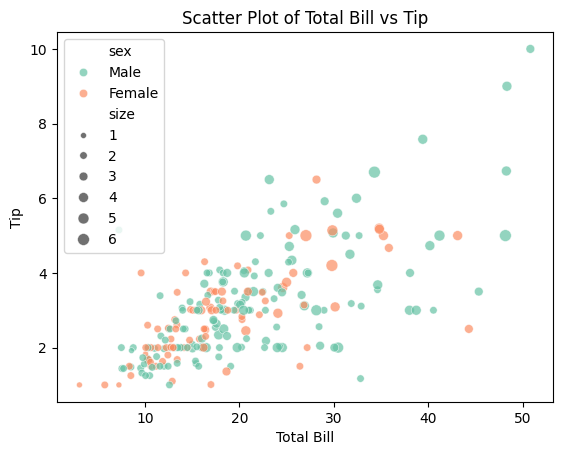

In [40]:
sns.scatterplot(x='total_bill', y='tip', data=df, hue='sex', size='size', alpha=0.7, palette='Set2')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Scatter Plot of Total Bill vs Tip')
plt.show()

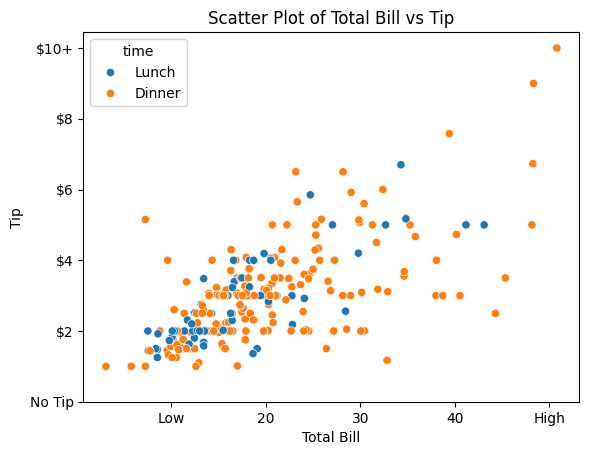

In [41]:
sns.scatterplot(x='total_bill', y='tip', hue='time', data=df)

custom_x_ticks = [10, 20, 30, 40, 50]
custom_x_labels = ['Low', 20, 30, 40, 'High']
plt.xticks(custom_x_ticks, custom_x_labels)

custom_y_ticks = [0, 2, 4, 6, 8, 10]
custom_y_labels = ['No Tip', '$2', '$4', '$6', '$8', '$10+']
plt.yticks(custom_y_ticks, custom_y_labels)

plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Scatter Plot of Total Bill vs Tip')
plt.show()

Text(0, 0.5, 'Tip')

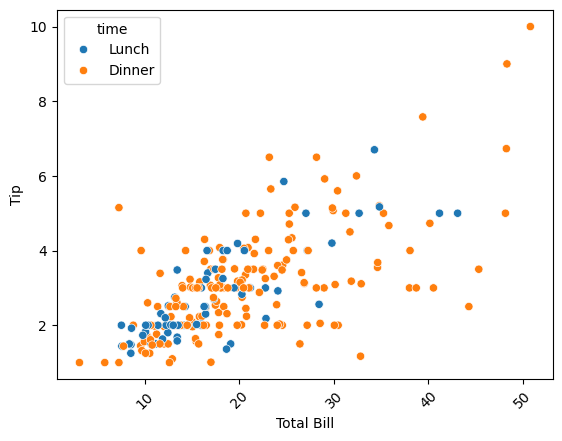

In [42]:
sns.scatterplot(x='total_bill', y='tip', hue='time', data=df)
plt.xticks(rotation=45)
plt.xlabel('Total Bill')
plt.ylabel('Tip')